multi-hazard, multi-phenomenon analysis. Since you have earthquakes (~80k events) and solar flares (~2k events) over the same 3-year window, the goal is temporal and categorical comparisons.

Because your solar flare dataset is much smaller, the analysis will focus on temporal alignment and trend comparison, rather than one-to-one event matching.

### set up

In [1]:
import sys
from pathlib import Path
import os
print(os.getcwd())

/Users/paus/Projects/da_capstone/notebooks/04_correlation_analysis.ipynb


In [2]:
# Go up ONE level from current directory
project_root = Path().resolve().parents[0]   # current dir
project_root = project_root.parent           # go up one level

sys.path.append(str(project_root))

print(project_root)
from src.imports import *

/Users/paus/Projects/da_capstone


### Load files

In [5]:
# Path to your interim file
file_gst_path = "/Users/paus/Projects/da_capstone/data/processed/nasa_gst_df.csv"
file_flr_path = "/Users/paus/Projects/da_capstone/data/processed/nasa_flr_df.csv"
file_eq_path = "/Users/paus/Projects/da_capstone/data/processed/usgs_eq_df.csv"
file_kp_path = "/Users/paus/Projects/da_capstone/data/processed/gfz_kp_df.csv"

# Load CSV into a DataFrame
nasa_gst_df = pd.read_csv(file_gst_path)
nasa_flr_df = pd.read_csv(file_flr_path)
gfz_kp_df = pd.read_csv(file_kp_path)
usgs_eq_df = pd.read_csv(file_eq_path)

In [6]:
nasa_flr_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2961 entries, 0 to 2960
Data columns (total 21 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   id_flr                        2961 non-null   object 
 1   num_linked_events             2961 non-null   int64  
 2   start_time                    2961 non-null   object 
 3   peak_time                     2961 non-null   object 
 4   end_time                      2920 non-null   object 
 5   general_source_location       2961 non-null   object 
 6   solar_flare_flux_class        2961 non-null   object 
 7   submission_time               2961 non-null   object 
 8   chronology_valid              2961 non-null   bool   
 9   start_time_date               2961 non-null   object 
 10  start_time_hour_decimal       2961 non-null   float64
 11  peak_time_date                2961 non-null   object 
 12  peak_time_hour_decimal        2961 non-null   float64
 13  end

### Timestamps

###### 1️⃣ Standardize timestamps

In [17]:
import pandas as pd

# Convert start_time to datetime and set UTC
for df in [nasa_gst_df, nasa_flr_df, gfz_kp_df, usgs_eq_df]:
    df["start_time"] = pd.to_datetime(df["start_time"], utc=True)

In [18]:
nasa_flr_df.shape

(2961, 21)

In [19]:
# min, max, median
print(usgs_eq_df["start_time"].min())
print(usgs_eq_df["start_time"].max())
print(usgs_eq_df["start_time"].median())

2014-01-01 00:01:16.610000+00:00
2025-12-30 23:51:36.674000+00:00
2019-12-29 02:55:08.060000+00:00


In [20]:
usgs_eq_df["start_time"].isna().sum()

np.int64(0)

###### 2️⃣ Resample / round to hourly intervals

In [21]:
for df in [nasa_gst_df, nasa_flr_df, usgs_eq_df]:
    df["hour"] = df["start_time"].dt.floor("H")

/var/folders/22/x35lghc57lv81gc8j1th1dm80000gn/T/ipykernel_30941/1518606820.py:2: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df["hour"] = df["start_time"].dt.floor("H")
/var/folders/22/x35lghc57lv81gc8j1th1dm80000gn/T/ipykernel_30941/1518606820.py:2: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df["hour"] = df["start_time"].dt.floor("H")
/var/folders/22/x35lghc57lv81gc8j1th1dm80000gn/T/ipykernel_30941/1518606820.py:2: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df["hour"] = df["start_time"].dt.floor("H")


In [22]:
gfz_kp_df["hour"] = gfz_kp_df["start_time"].dt.floor("H")

/var/folders/22/x35lghc57lv81gc8j1th1dm80000gn/T/ipykernel_30941/3971608444.py:1: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  gfz_kp_df["hour"] = gfz_kp_df["start_time"].dt.floor("H")


###### 3️⃣ Aggregate counts / summaries per hour

In [ ]:
kp_hourly = gfz_kp_df.groupby("hour")["kp"].mean().reset_index()

flr_hourly = nasa_flr_df.groupby("hour").agg(
    flare_count=("start_time", "count"),
    flare_max_mag=("flare_intensity_numeric", "max")  #  magnitude column 
).reset_index()

eq_hourly = usgs_eq_df.groupby("hour").agg(
    eq_count=("start_time", "count"),
    eq_max_mag=("mag", "max")  # assuming magnitude column
).reset_index()

###### 4️⃣ Merge datasets into a single time-indexed DataFrame

In [14]:
# Start from Kp hours as base
hourly_df = kp_hourly.merge(flr_hourly, on="hour", how="outer")
hourly_df = hourly_df.merge(eq_hourly, on="hour", how="outer")

# Fill NaNs with 0 for counts
hourly_df[["flare_count","eq_count"]] = hourly_df[["flare_count","eq_count"]].fillna(0)

In [15]:
hourly_df["kp_category"] = pd.cut(
    hourly_df["kp"],
    bins=[-1,1,3,4,5,6,7,9],
    labels=["quiet","unsettled","active","minor_storm","moderate_storm","strong_storm","severe_storm"]
)

### visualizations

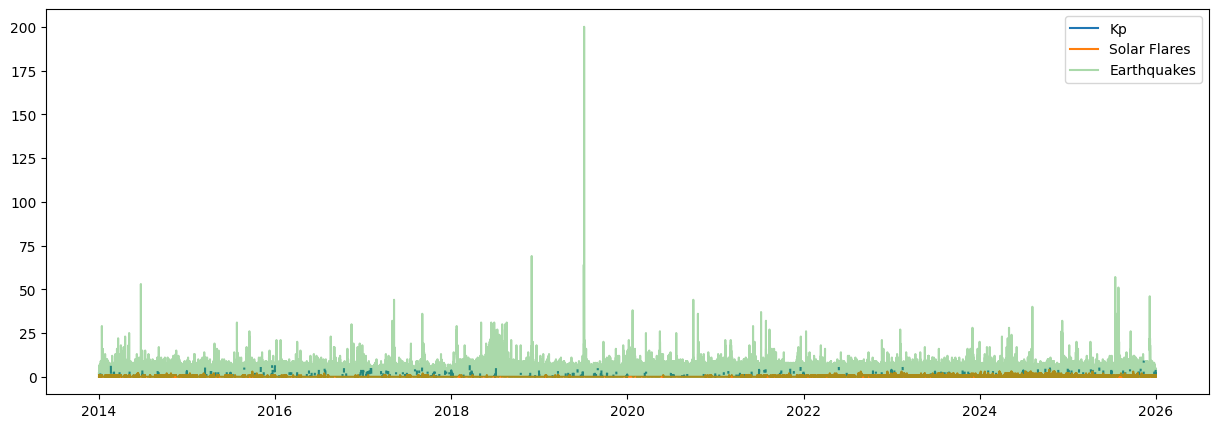

In [16]:
plt.figure(figsize=(15,5))
plt.plot(hourly_df["hour"], hourly_df["kp"], label="Kp")
plt.plot(hourly_df["hour"], hourly_df["flare_count"], label="Solar Flares")
plt.plot(hourly_df["hour"], hourly_df["eq_count"], label="Earthquakes", alpha = 0.4)
plt.legend()
plt.show()

###### 1️⃣ Resample to daily

In [17]:
# Set hour as index
hourly_df = hourly_df.set_index("hour")

# Aggregate to daily
daily_df = pd.DataFrame()
daily_df["kp_mean"] = hourly_df["kp"].resample("D").mean()
daily_df["eq_count"] = hourly_df["eq_count"].resample("D").sum()
daily_df["flare_count"] = hourly_df["flare_count"].resample("D").sum()

In [18]:
daily_df["earthquake_norm"] = (daily_df["eq_count"] - daily_df["eq_count"].mean()) / daily_df["eq_count"].std()
daily_df["solar_flare_norm"] = (daily_df["flare_count"] - daily_df["flare_count"].mean()) / daily_df["flare_count"].std()
daily_df["kp_norm"] = (daily_df["kp_mean"] - daily_df["kp_mean"].mean()) / daily_df["kp_mean"].std()

###### Normalized Time series

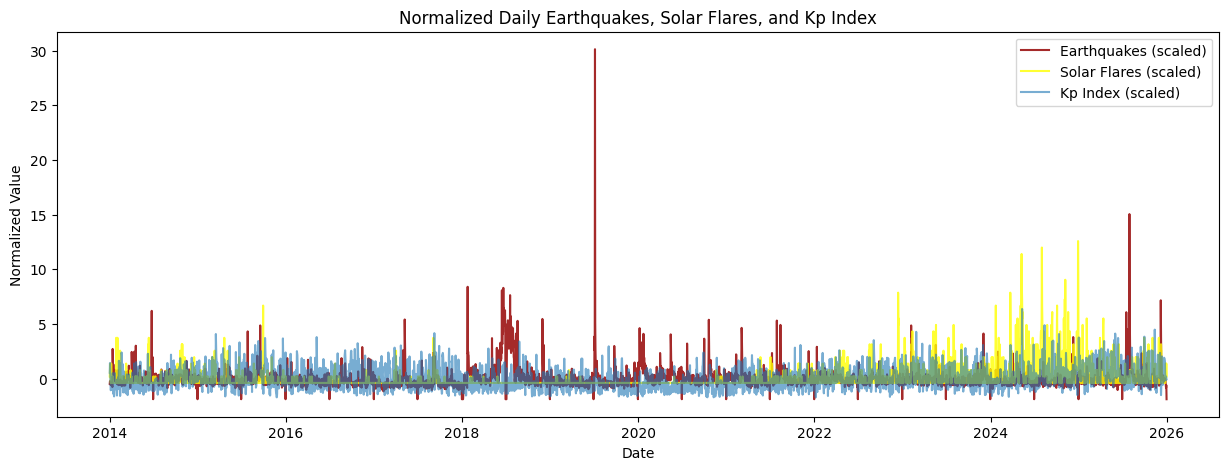

In [19]:
plt.figure(figsize=(15,5))
plt.plot(daily_df.index, daily_df["earthquake_norm"], label="Earthquakes (scaled)", color = "brown")
plt.plot(daily_df.index, daily_df["solar_flare_norm"], label="Solar Flares (scaled)", alpha = 0.8, color = "yellow")
plt.plot(daily_df.index, daily_df["kp_norm"], label="Kp Index (scaled)", alpha = 0.6)
plt.legend()
plt.title("Normalized Daily Earthquakes, Solar Flares, and Kp Index")
plt.xlabel("Date")
plt.ylabel("Normalized Value")
plt.show()

##### Categorical Analysis

In [20]:
# First, ensure start_time is datetime and in UTC
usgs_eq_df["start_time"] = pd.to_datetime(usgs_eq_df["start_time"], utc=True)
gfz_kp_df["start_time"] = pd.to_datetime(gfz_kp_df["start_time"], utc=True)

# Resample to daily
usgs_eq_df["day"] = usgs_eq_df["start_time"].dt.floor("D")
gfz_kp_df["day"] = gfz_kp_df["start_time"].dt.floor("D")

In [21]:
# Define the order of KP categories
kp_order = ["quiet","unsettled","active","minor_storm","moderate_storm","strong_storm","severe_storm"]

# Convert to ordered categorical
gfz_kp_df["kp_category"] = pd.Categorical(
    gfz_kp_df["kp_category"],
    categories=kp_order,
    ordered=True
)

In [22]:
kp_daily = gfz_kp_df.groupby(["day", "kp_category"]).size().unstack(fill_value=0)

/var/folders/22/x35lghc57lv81gc8j1th1dm80000gn/T/ipykernel_20748/935316601.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  kp_daily = gfz_kp_df.groupby(["day", "kp_category"]).size().unstack(fill_value=0)


In [23]:
kp_daily = kp_daily[kp_order]  # ensure correct column order

In [24]:
# categorize magnitudes
bins = [-float("inf"), 2, 4, 5, 7, 8, float("inf")]

labels = [
    "Micro",
    "Minor",
    "Moderate",
    "Strong",
    "Major",
    "Great"
]

usgs_eq_df["mag_category"] = pd.cut(
    usgs_eq_df["mag"],
    bins=bins,
    labels=labels
)

In [25]:
eq_daily = usgs_eq_df.groupby(["day", "mag_category"]).size().unstack(fill_value=0)

/var/folders/22/x35lghc57lv81gc8j1th1dm80000gn/T/ipykernel_20748/3705741265.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  eq_daily = usgs_eq_df.groupby(["day", "mag_category"]).size().unstack(fill_value=0)


In [26]:
eq_daily_norm = eq_daily.div(eq_daily.sum(axis=1), axis=0)
kp_daily_norm = kp_daily.div(kp_daily.sum(axis=1), axis=0)

In [30]:
eq_colors = {
    "Micro": "#1A8B60",      # light yellow
    "Minor": "#B2FF66",      # light green
    "Moderate": "#F7F749",
    "Strong": "#D9A13F",      # medium green
    "Major": "#B26315",   # brown
    "Great": "#B73408"      # dark brown
}

In [28]:
kp_colors = {
    "quiet": "#FFFFB2",         # pale yellow
    "unsettled": "#FFD700",     # golden yellow
    "active": "#FFA500",        # orange
    "minor_storm": "#FF69B4",   # pink
    "moderate_storm": "#FF1493",# deep pink
    "strong_storm": "#8B0058",  # dark magenta
    "severe_storm": "#1303A4"   # indigo / reddish-purple
}

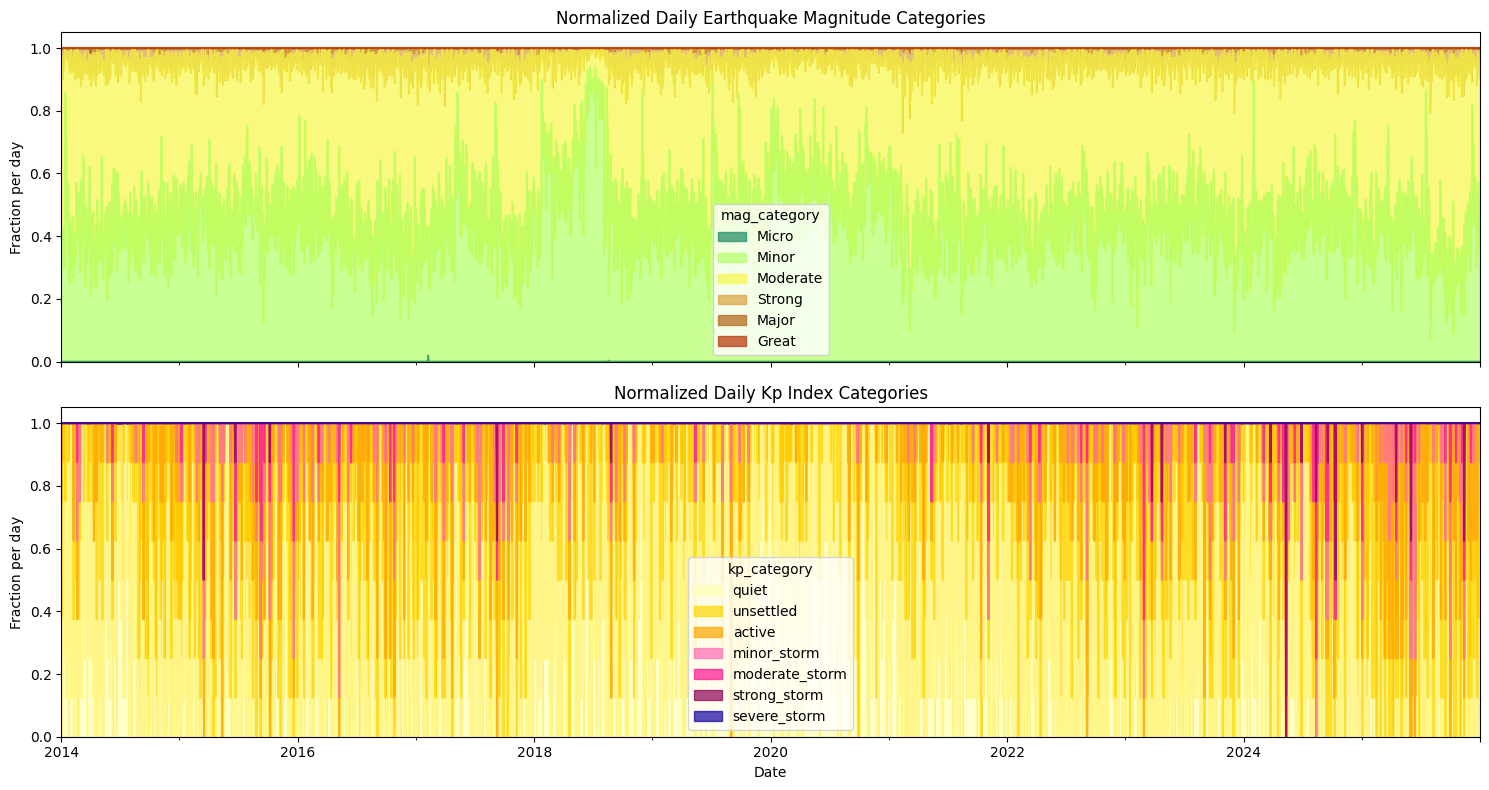

In [31]:
fig, axs = plt.subplots(2, 1, figsize=(15,8), sharex=True)

eq_daily_norm.plot.area(ax=axs[0], alpha=0.7, color=[eq_colors[c] for c in eq_daily.columns])
axs[0].set_title("Normalized Daily Earthquake Magnitude Categories")
axs[0].set_ylabel("Fraction per day")

kp_daily_norm.plot.area(ax=axs[1], alpha=0.7, color=[kp_colors[c] for c in kp_daily.columns])
axs[1].set_title("Normalized Daily Kp Index Categories")
axs[1].set_ylabel("Fraction per day")

plt.xlabel("Date")
plt.tight_layout()
plt.show()

#### Geospatial Analyis

### Outdated

In [47]:
# Convert from milliseconds to datetime (UTC)
usgs_eq_df["start_time"] = pd.to_datetime(usgs_eq_df["start_time"], utc=True)

print(usgs_eq_df[["start_time"]].head())

                        start_time
0 2023-06-29 23:43:39.818000+00:00
1 2023-06-29 23:18:27.963000+00:00
2 2023-06-29 22:54:12.700000+00:00
3 2023-06-29 22:48:28.050000+00:00
4 2023-06-29 21:30:17.967000+00:00


In [48]:
# Convert All Time Columns to Proper UTC Datetime
time_cols = ["start_time", "peak_time", "end_time", "submission_time"]

for col in time_cols:
    nasa_flr_df[col] = pd.to_datetime(nasa_flr_df[col], utc=True, errors="coerce")

print(nasa_flr_df[["start_time"]].head())

                 start_time
0 2014-01-01 18:40:00+00:00
1 2014-01-02 02:24:00+00:00
2 2014-01-02 22:12:00+00:00
3 2014-01-03 12:41:00+00:00
4 2014-01-03 21:00:00+00:00


In [49]:
# Convert from milliseconds to datetime (UTC)
gfz_kp_df["start_time"] = pd.to_datetime(gfz_kp_df["start_time"], utc=True)

print(gfz_kp_df[["start_time"]].head())

                 start_time
0 2014-01-01 00:00:00+00:00
1 2014-01-01 03:00:00+00:00
2 2014-01-01 06:00:00+00:00
3 2014-01-01 09:00:00+00:00
4 2014-01-01 12:00:00+00:00


In [50]:
#NOT EXECUTE
# Solar flares 
nasa_flr_df["start_time"] = pd.to_datetime(nasa_flr_df["start_time"], errors="coerce", utc=True)
nasa_flr_df["peak_time"]  = pd.to_datetime(nasa_flr_df["peak_time"], errors="coerce", utc=True)
nasa_flr_df["end_time"]   = pd.to_datetime(nasa_flr_df["end_time"], errors="coerce", utc=True)

# Earthquakes
usgs_eq_df["start_time"] = pd.to_datetime(usgs_eq_df["start_time"], errors="coerce", utc=True)

In [51]:
nasa_flr_df["start_time"] = nasa_flr_df["start_time"].dt.tz_convert(None)
nasa_flr_df["peak_time"]  = nasa_flr_df["peak_time"].dt.tz_convert(None)
nasa_flr_df["end_time"]   = nasa_flr_df["end_time"].dt.tz_convert(None)

usgs_eq_df["start_time"] = usgs_eq_df["start_time"].dt.tz_convert(None)

gfz_kp_df["start_time"] = gfz_kp_df["start_time"].dt.tz_convert(None)

#### .

In [52]:
# Earthquakes
usgs_eq_df = usgs_eq_df.set_index("start_time")

# Solar flares
nasa_flr_df = nasa_flr_df.set_index("start_time")

# KP Indix 
gfz_kp_df = gfz_kp_df.set_index("start_time")

In [53]:
# Earthquakes per day
eq_daily = usgs_eq_df["id_eq"].resample("D").count().rename("earthquake_count")

# Solar flares per day
flare_daily = nasa_flr_df["id_flr"].resample("D").count().rename("solar_flare_count")

# Solar flares per day
kpi_daily = gfz_kp_df["start_time"].resample("D").count().rename("kp_index_count")

# Average flare class per day (optional)
avg_flux_daily = nasa_flr_df["solar_flare_flux_class"].str[0].map({"A":1,"B":2,"C":3,"M":4,"X":5})
avg_flux_daily = avg_flux_daily.resample("D").mean().rename("avg_flux_class")

# Combine
daily_df = pd.concat([eq_daily, kpi_daily, flare_daily, avg_flux_daily], axis=1).fillna(0)
daily_df.head()

KeyError: 'start_time'

In [14]:
# Earthquakes per hour
eq_hourly = usgs_eq_df["id_eq"].resample("h").count().rename("earthquake_count")

# Solar flares per hour
flare_hourly = nasa_flr_df["id_flr"].resample("h").count().rename("solar_flare_count")

# Combine
hourly_df = pd.concat([eq_hourly, flare_hourly], axis=1).fillna(0)
hourly_df.head()

,earthquake_count,solar_flare_count
start_time,,
2014-01-01 00:00:00,2.0,0.0
2014-01-01 01:00:00,3.0,0.0
2014-01-01 02:00:00,1.0,0.0
2014-01-01 03:00:00,2.0,0.0
2014-01-01 04:00:00,4.0,0.0


In [73]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15,5))
plt.plot(hourly_df.index, hourly_df["earthquake_count"], label="Earthquakes", color="tab:blue")
plt.plot(hourly_df.index, hourly_df["solar_flare_count"], label="Solar Flares", color="tab:orange", alpha=0.7)
plt.xlabel("Date & Hour")
plt.ylabel("Count")
plt.title("Hourly Earthquakes vs Solar Flares")
plt.legend()
plt.show()

KeyError: 'earthquake_count'

<Figure size 1500x500 with 0 Axes>

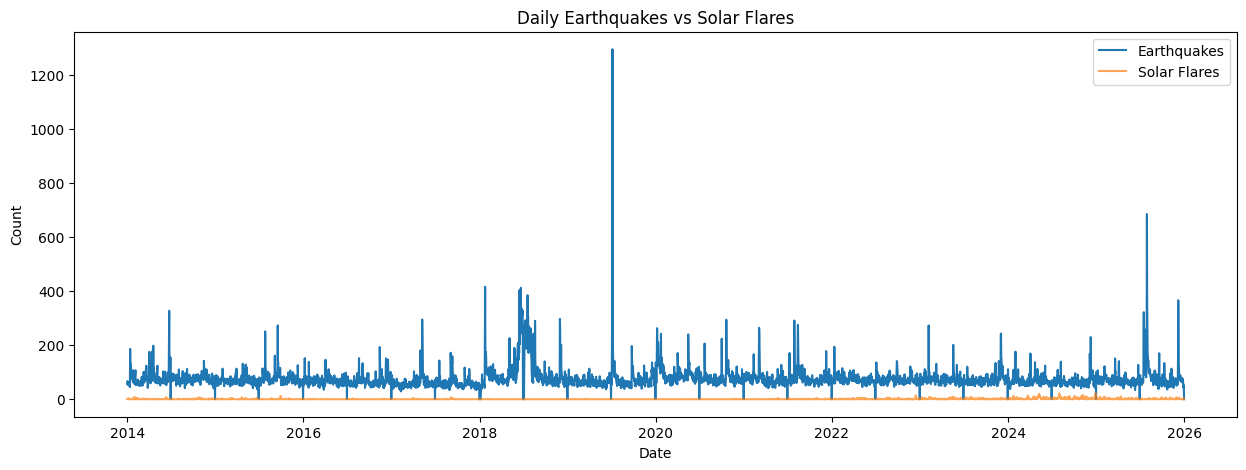

In [13]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15,5))
plt.plot(daily_df.index, daily_df["earthquake_count"], label="Earthquakes", color="tab:blue")
plt.plot(daily_df.index, daily_df["solar_flare_count"], label="Solar Flares", color="tab:orange", alpha=0.7)
plt.xlabel("Date")
plt.ylabel("Count")
plt.title("Daily Earthquakes vs Solar Flares")
plt.legend()
plt.show()

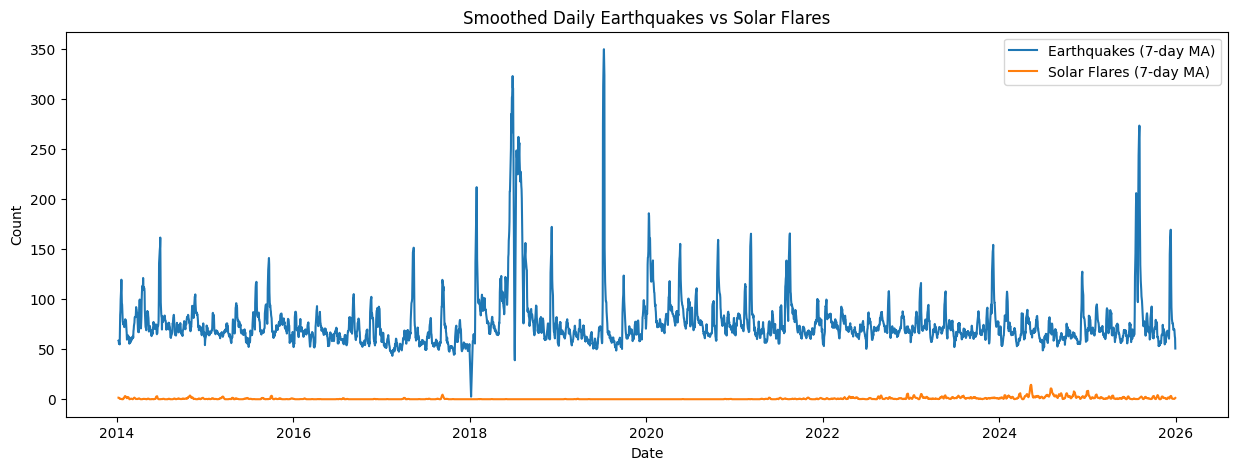

In [14]:
daily_df["eq_7d"] = daily_df["earthquake_count"].rolling(7).mean()
daily_df["flare_7d"] = daily_df["solar_flare_count"].rolling(7).mean()

plt.figure(figsize=(15,5))
plt.plot(daily_df.index, daily_df["eq_7d"], label="Earthquakes (7-day MA)")
plt.plot(daily_df.index, daily_df["flare_7d"], label="Solar Flares (7-day MA)")
plt.xlabel("Date")
plt.ylabel("Count")
plt.title("Smoothed Daily Earthquakes vs Solar Flares")
plt.legend()
plt.show()

In [15]:
daily_df[["earthquake_count","solar_flare_count"]].corr()

,earthquake_count,solar_flare_count
earthquake_count,1.000000,-0.031009
solar_flare_count,-0.031009,1.000000


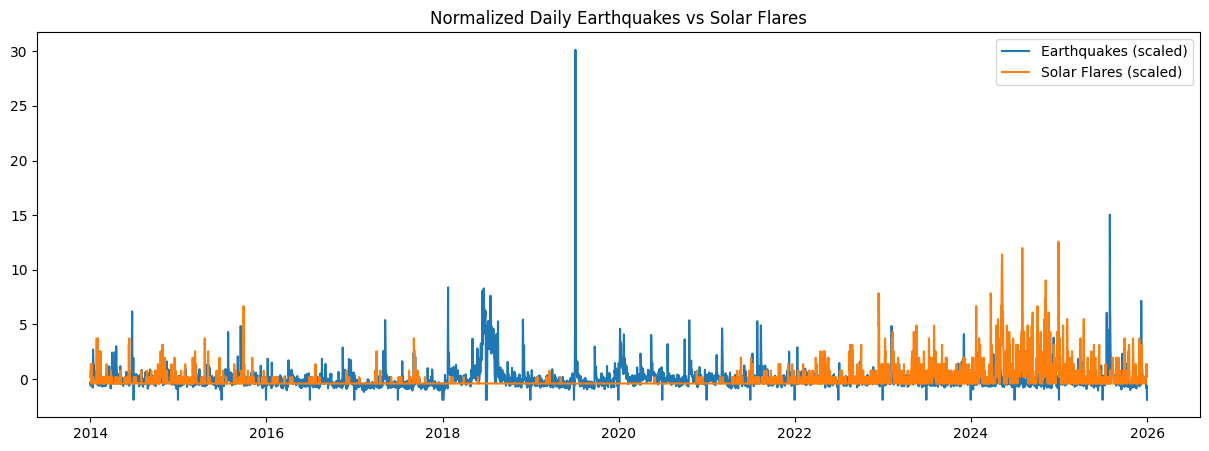

In [16]:
daily_df["earthquake_norm"] = (daily_df["earthquake_count"] - daily_df["earthquake_count"].mean()) / daily_df["earthquake_count"].std()
daily_df["solar_flare_norm"] = (daily_df["solar_flare_count"] - daily_df["solar_flare_count"].mean()) / daily_df["solar_flare_count"].std()

plt.figure(figsize=(15,5))
plt.plot(daily_df.index, daily_df["earthquake_norm"], label="Earthquakes (scaled)")
plt.plot(daily_df.index, daily_df["solar_flare_norm"], label="Solar Flares (scaled)")
plt.legend()
plt.title("Normalized Daily Earthquakes vs Solar Flares")
plt.show()

In [25]:
pip install pycountry

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.0/8.0 MB 29.4 MB/s  0:00:00 eta 0:00:01
Note: you may need to restart the kernel to use updated packages.
